<a href="https://colab.research.google.com/github/sgarciarod/alzheimers-classification-shallow-vs-deep-nn/blob/main/01_perceptron_simple_rosenblatt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptrón Simple de Rosenblatt

## Introducción Teórica

### Historia y Contexto

El **Perceptrón** fue propuesto por **Frank Rosenblatt** en 1958 como uno de los primeros modelos computacionales de una neurona biológica. Inspirado en el trabajo de McCulloch y Pitts (1943), Rosenblatt desarrolló un algoritmo capaz de aprender a clasificar patrones linealmente separables (clasificación binaria lineal)

El perceptrón fue implementado originalmente en hardware (la máquina Mark I Perceptron) y representó un hito en la historia de la inteligencia artificial.

### Descripción Matemática

Dado un vector de entradas $\mathbf{x} = [x_1, x_2, ..., x_n]$ y pesos $\mathbf{w} = [w_1, w_2, ..., w_n]$:

**Entrada neta:**
$$z = \mathbf{w} \cdot \mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b$$

**Función de activación (función escalón):**
$$\hat{y} = \text{sign}(z) = \begin{cases} 1 & \text{si } z \geq 0 \\ -1 & \text{si } z < 0 \end{cases}$$

### Regla de Aprendizaje

El perceptrón actualiza sus pesos según la regla de Rosenblatt:

$$\mathbf{w} = \mathbf{w} + \eta (y - \hat{y}) \mathbf{x}$$

Donde:
- $\eta$ es la **tasa de aprendizaje** (learning rate)
- $y$ es la etiqueta real
- $\hat{y}$ es la predicción del modelo

### Limitaciones

> ⚠️ **Teorema de convergencia del Perceptrón**: El algoritmo converge en un número finito de pasos **si y solo si** los datos son **linealmente separables**.

El perceptrón **no puede** resolver problemas no linealmente separables como la función XOR, lo que fue señalado por Minsky y Papert en su libro "Perceptrons" (1969) y generó el primer "invierno de la IA".

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(1)

class Perceptron:
    """Implementación del Perceptrón de Rosenblatt."""

    def __init__(self, eta=0.1, n_iter=50):
        self.eta = eta      # tasa de aprendizaje
        self.n_iter = n_iter  # número de épocas

    def fit(self, X, y):
        """Entrenar el perceptrón con los datos X y etiquetas y."""
        self.w_ = np.zeros(1 + X.shape[1])  # pesos (w[0] = sesgo)
        self.errors_ = []  # errores por época

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                # Calcular predicción y actualizar pesos
                prediction = self.predict(xi)
                update = self.eta * (target - prediction)
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calcular la entrada neta: z = w · x + b"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        """Predecir la etiqueta de clase usando la función escalón."""
        return np.where(self.net_input(X) >= 0.0, 1, -1)

print("Clase Perceptron definida correctamente.")
print(f"Parámetros por defecto: eta=0.1, n_iter=50")

Clase Perceptron definida correctamente.
Parámetros por defecto: eta=0.1, n_iter=50


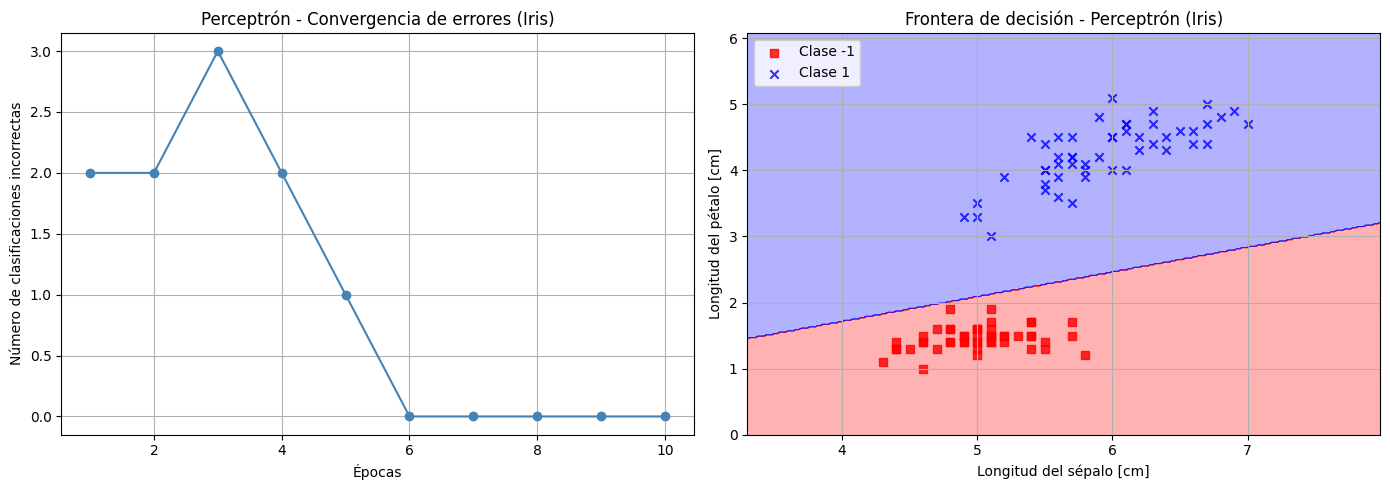

Errores por época: [2, 2, 3, 2, 1, 0, 0, 0, 0, 0]
Pesos finales: [-0.4  -0.68  1.82]


In [ ]:
from sklearn.datasets import load_iris

# Cargar dataset Iris
iris = load_iris()
X = iris.data[:100, [0, 2]]  # sepal length, petal length
y = iris.target[:100]
y = np.where(y == 0, -1, 1)  # convertir a -1 y 1

# Entrenar el perceptrón
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)

# Graficar errores por época
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o', color='steelblue')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Número de clasificaciones incorrectas')
axes[0].set_title('Perceptrón - Convergencia de errores (Iris)')
axes[0].grid(True)

# Graficar frontera de decisión
def plot_decision_regions(X, y, classifier, axes, resolution=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                            np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    axes.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    axes.set_xlim(xx1.min(), xx1.max())
    axes.set_ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        axes.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=colors[idx], marker=markers[idx], label=f'Clase {cl}')

plot_decision_regions(X, y, ppn, axes[1])
axes[1].set_xlabel('Longitud del sépalo [cm]')
axes[1].set_ylabel('Longitud del pétalo [cm]')
axes[1].set_title('Frontera de decisión - Perceptrón (Iris)')
axes[1].legend(loc='upper left')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/tmp/perceptron_iris.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Errores por época: {ppn.errors_}")
print(f"Pesos finales: {ppn.w_}")

## Ejemplo 2: Compuertas Lógicas AND y OR

Las compuertas lógicas AND y OR son problemas **linealmente separables**, lo que significa que el Perceptrón puede aprenderlas perfectamente.

### Compuerta AND
| x1 | x2 | AND |
|----|----|----|
| 0  | 0  | -1 |
| 0  | 1  | -1 |
| 1  | 0  | -1 |
| 1  | 1  |  1 |

### Compuerta OR
| x1 | x2 | OR |
|----|----|----|
| 0  | 0  | -1 |
| 0  | 1  |  1 |
| 1  | 0  |  1 |
| 1  | 1  |  1 |

Ambas funciones pueden separarse con una línea recta en el espacio de características, por lo que el Perceptrón converge garantizadamente.

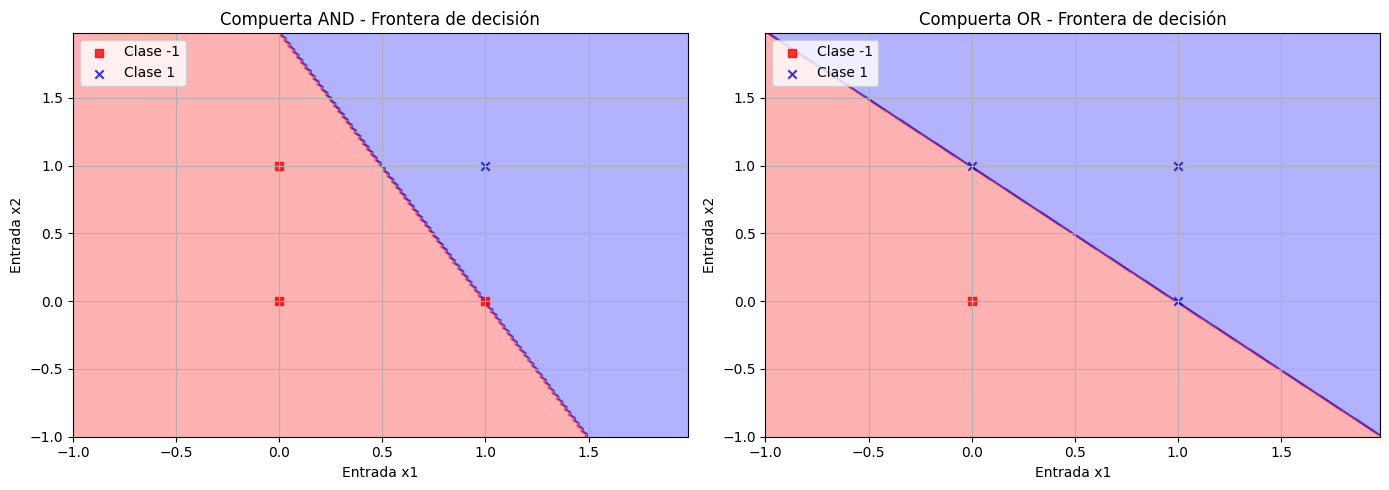

AND - Predicciones: [-1 -1 -1  1], Esperado: [-1 -1 -1  1]
OR  - Predicciones: [-1  1  1  1], Esperado: [-1  1  1  1]


In [ ]:
# Compuerta AND
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([-1, -1, -1, 1])  # AND: solo 1 cuando ambos son 1

# Compuerta OR
y_or = np.array([-1, 1, 1, 1])   # OR: 1 cuando al menos uno es 1

ppn_and = Perceptron(eta=0.1, n_iter=20)
ppn_and.fit(X_and, y_and)

ppn_or = Perceptron(eta=0.1, n_iter=20)
ppn_or.fit(X_and, y_or)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_regions(X_and, y_and, ppn_and, axes[0])
axes[0].set_title('Compuerta AND - Frontera de decisión')
axes[0].set_xlabel('Entrada x1')
axes[0].set_ylabel('Entrada x2')
axes[0].legend(loc='upper left')
axes[0].grid(True)

plot_decision_regions(X_and, y_or, ppn_or, axes[1])
axes[1].set_title('Compuerta OR - Frontera de decisión')
axes[1].set_xlabel('Entrada x1')
axes[1].set_ylabel('Entrada x2')
axes[1].legend(loc='upper left')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/tmp/perceptron_and_or.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"AND - Predicciones: {ppn_and.predict(X_and)}, Esperado: {y_and}")
print(f"OR  - Predicciones: {ppn_or.predict(X_and)}, Esperado: {y_or}")

## Ejemplo 3: La Limitación del XOR

### El Problema XOR

La función XOR (OR exclusivo) es el ejemplo clásico de un problema **NO linealmente separable**:

| x1 | x2 | XOR |
|----|----|----|
| 0  | 0  | -1 |
| 0  | 1  |  1 |
| 1  | 0  |  1 |
| 1  | 1  | -1 |

No existe ninguna línea recta que pueda separar correctamente las clases. Los puntos de clase 1 están en las esquinas diagonalmente opuestas (0,1) y (1,0), mientras que los puntos de clase -1 están en (0,0) y (1,1).

### Consecuencias Históricas

Esta limitación fue destacada por **Minsky y Papert** en 1969, lo que llevó al primer "invierno de la IA". La solución llegó con las **redes neuronales multicapa** y el algoritmo de **retropropagación** (backpropagation), que permiten aprender representaciones no lineales.

> 💡 **Conclusión**: Para resolver XOR necesitamos al menos una capa oculta con funciones de activación no lineales — lo que se conoce como **Perceptrón Multicapa (MLP)**.

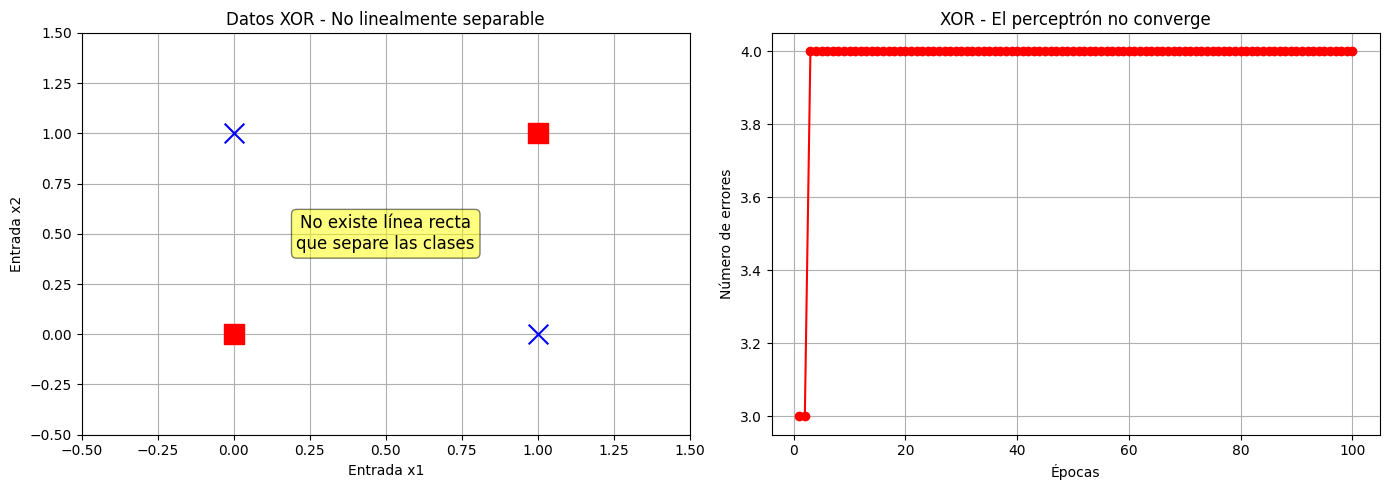

XOR - Predicciones: [ 1  1 -1 -1], Esperado: [-1  1  1 -1]
Errores en última época: 4 (nunca llega a 0)


In [ ]:
# Compuerta XOR - no linealmente separable
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([-1, 1, 1, -1])   # XOR

ppn_xor = Perceptron(eta=0.1, n_iter=100)
ppn_xor.fit(X_xor, y_xor)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualizar datos XOR
colors = {-1: 'red', 1: 'blue'}
markers = {-1: 's', 1: 'x'}
for idx in range(len(X_xor)):
    axes[0].scatter(X_xor[idx, 0], X_xor[idx, 1],
                   c=colors[y_xor[idx]], marker=markers[y_xor[idx]],
                   s=200, zorder=5)
axes[0].set_title('Datos XOR - No linealmente separable')
axes[0].set_xlabel('Entrada x1')
axes[0].set_ylabel('Entrada x2')
axes[0].set_xlim(-0.5, 1.5)
axes[0].set_ylim(-0.5, 1.5)
axes[0].grid(True)
axes[0].text(0.5, 0.5, 'No existe línea recta\nque separe las clases',
            ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Graficar errores del XOR (nunca converge a 0)
axes[1].plot(range(1, len(ppn_xor.errors_) + 1), ppn_xor.errors_, marker='o', color='red')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Número de errores')
axes[1].set_title('XOR - El perceptrón no converge')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/tmp/perceptron_xor.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"XOR - Predicciones: {ppn_xor.predict(X_xor)}, Esperado: {y_xor}")
print(f"Errores en última época: {ppn_xor.errors_[-1]} (nunca llega a 0)")

## Referencias Bibliográficas

1. **Rosenblatt, F.** (1958). *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*. Psychological Review, 65(6), 386–408.

2. **McCulloch, W. S., & Pitts, W.** (1943). *A Logical Calculus of the Ideas Immanent in Nervous Activity*. Bulletin of Mathematical Biophysics, 5(4), 115–133.

3. **Minsky, M., & Papert, S.** (1969). *Perceptrons: An Introduction to Computational Geometry*. MIT Press.

4. **Raschka, S., & Mirjalili, V.** (2019). *Python Machine Learning* (3rd ed.). Packt Publishing.

5. **Goodfellow, I., Bengio, Y., & Courville, A.** (2016). *Deep Learning*. MIT Press. [Disponible en: https://www.deeplearningbook.org/]

---
*Notebook desarrollado para el curso de clasificación de Alzheimer - Comparativa entre redes neuronales superficiales y profundas.*